<a href="https://colab.research.google.com/github/rpark3/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%204%20/ECON3916_Assignment_4_The_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import missingno as msno
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import seaborn as sns

In [ ]:
url = "https://raw.githubusercontent.com/rpark3/ECON3916-Statistical-Machine-Learning/refs/heads/main/Data/OmniCare_Clinical_Vitals.csv"
url2 = "https://raw.githubusercontent.com/rpark3/ECON3916-Statistical-Machine-Learning/refs/heads/main/Data/OmniCare_Telemetry_Data.csv"

df = pd.read_csv(url)
df2 = pd.read_csv(url2)

In [ ]:
features = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]
X = df[features].dropna()
X_const = sm.add_constant(X)

for i in range(len(features)):
    vif = variance_inflation_factor(X_const.values, i+1)
    print(f"{features[i]}: {vif:.2f}")


Weight_kg: 57.43
Height_cm: 28.42
BMI: 16.98
Systolic_BP: 4.22
Diastolic_BP: 4.22


In [ ]:
features_2 = ["Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]
X2 = df[features_2].dropna()
X_const2 = sm.add_constant(X2)

for i in range(len(features_2)):
    vif = variance_inflation_factor(X_const2.values, i+1)
    print(f"{features_2[i]}: {vif:.2f}")

Weight_kg: 3.76
Height_cm: 3.76
Systolic_BP: 4.22
Diastolic_BP: 4.22


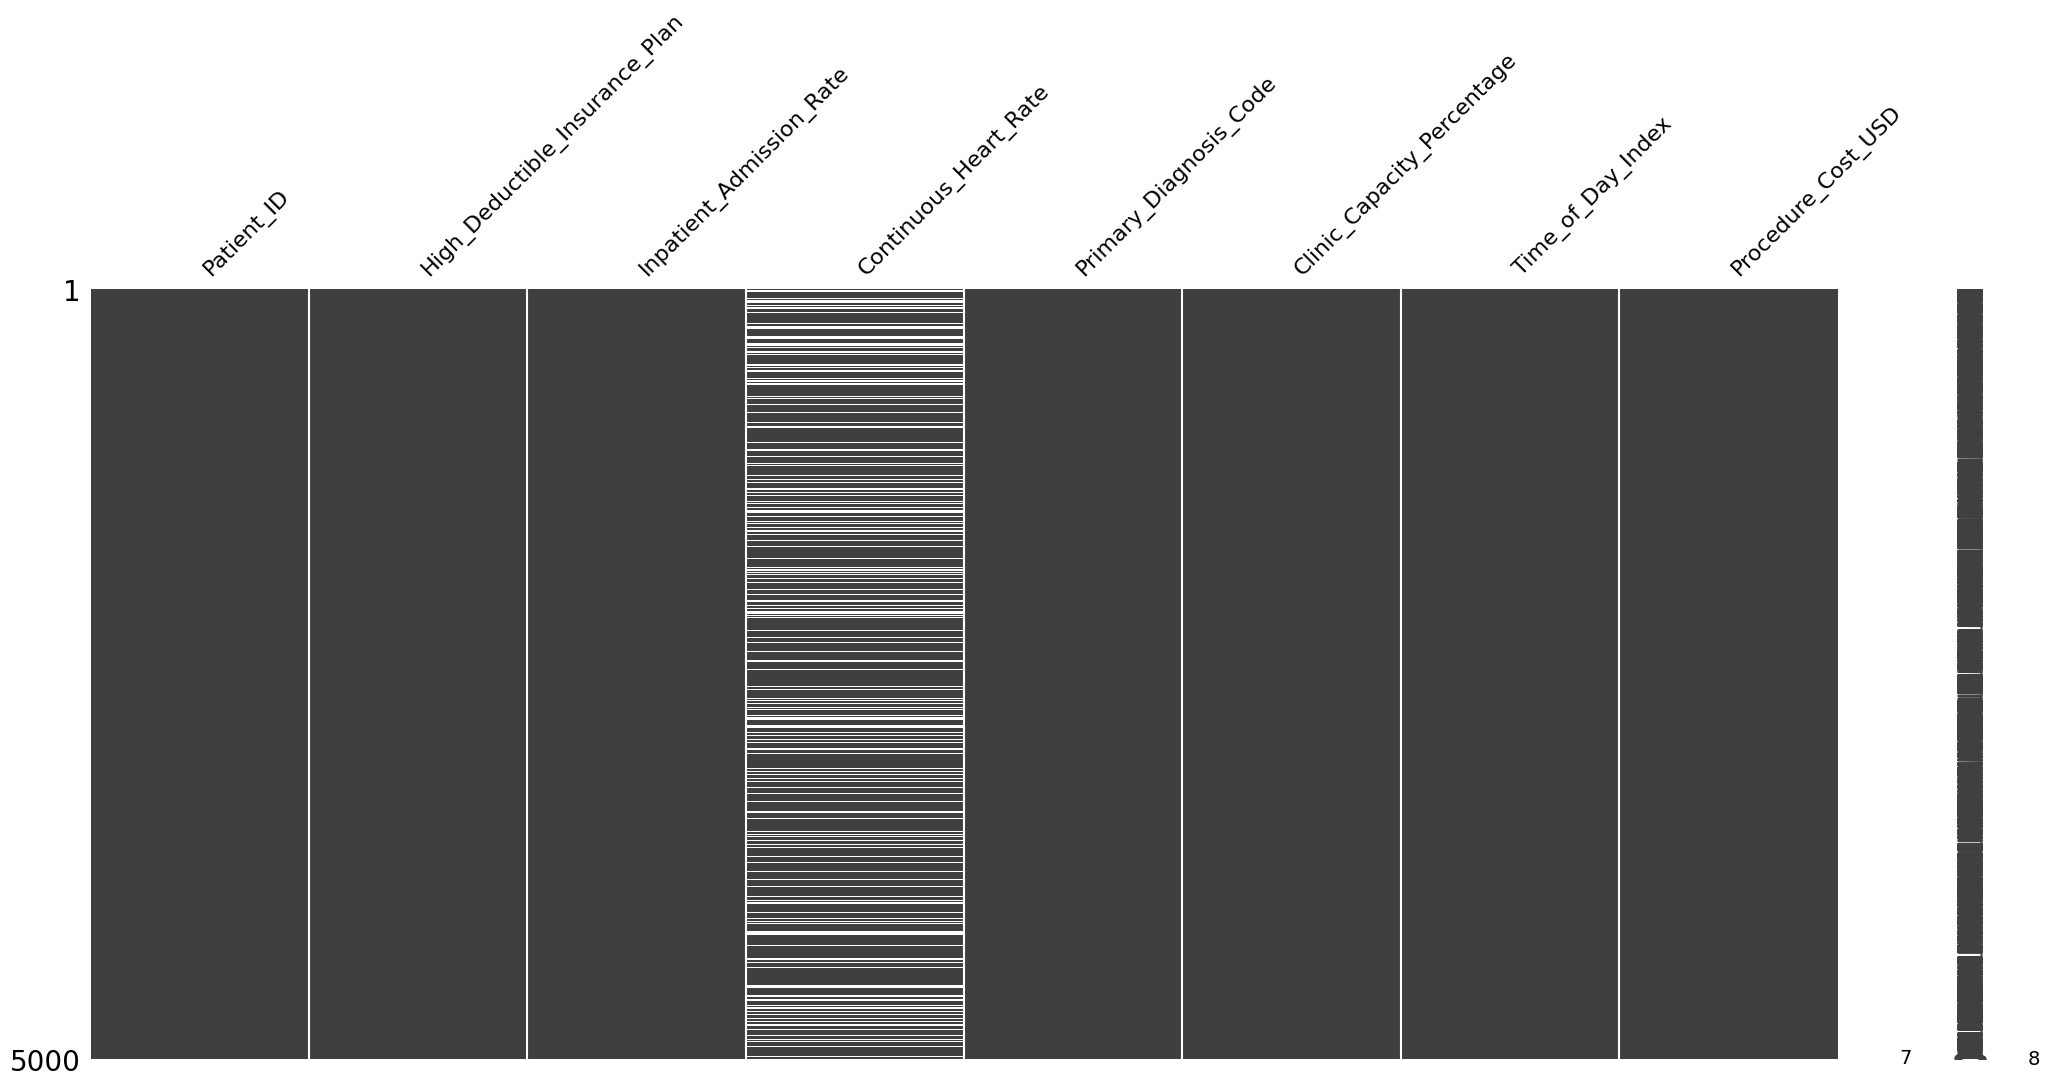

In [ ]:
msno.matrix(df2)
plt.show()

MNAR - Data missing is directly related to low income patients who cannot afford the data plan.

2.2 - When you have 850 dummy columns, every row sums to 1. The intercept is also a column of 1s. So you have two things that are identical, which means the matrix can't be inverted and OLS breaks.

In [ ]:
!pip install category_encoders -q

from category_encoders import TargetEncoder

encoder = TargetEncoder(cols="Primary_Diagnosis_Code")

df2["Primary_Diagnosis_Code"] = encoder.fit_transform(df2["Primary_Diagnosis_Code"], df2["Procedure_Cost_USD"])

print(df2["Primary_Diagnosis_Code"].head())

0    1707.697108
1    1792.303198
2    1730.334968
3    1725.060944
4    1801.821085
Name: Primary_Diagnosis_Code, dtype: float64


In [ ]:
df_model = pd.merge(df, df2, on="Patient_ID")

df_model["Target_Encoded_Diagnosis"] = encoder.fit_transform(
    df_model["Primary_Diagnosis_Code"],
    df_model["Procedure_Cost_USD"]
)

df_model = df_model[["Procedure_Cost_USD","Target_Encoded_Diagnosis","Clinic_Capacity_Percentage","Time_of_Day_Index","Weight_kg","Height_cm","Systolic_BP","Diastolic_BP"]].dropna()

formula = "Procedure_Cost_USD ~ Target_Encoded_Diagnosis + Clinic_Capacity_Percentage + Time_of_Day_Index + Weight_kg + Height_cm + Systolic_BP + Diastolic_BP"

model = smf.ols(formula=formula, data=df_model).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          6.83e-296
Time:                        22:23:04   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [ ]:
from statsmodels.tools.eval_measures import rmse

predicted = model.fittedvalues
actual = df_model["Procedure_Cost_USD"]

error = rmse(actual, predicted)
print(f"RMSE: ${error:.2f}")

RMSE: $334.80


A 450 average error on a 1200 procedure is a 37.5% error rate. Patients could be quoted 750 and billed 1200 or be quotes 1650 and billed 1200

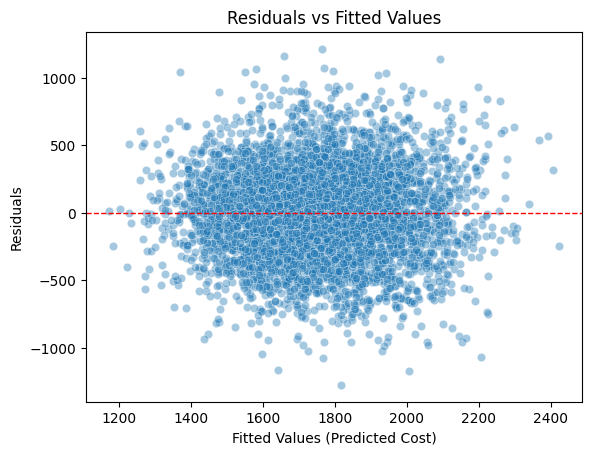

In [ ]:
residuals = model.resid

sns.scatterplot(x=predicted, y=residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Fitted Values (Predicted Cost)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import het_white

lm_stat, lm_pvalue, fstat, fpvalue = het_white(model.resid, model.model.exog)

print(f"LM Statistic: {lm_stat:.4f}")
print(f"P-Value: {lm_pvalue:.4f}")

if lm_pvalue < 0.05:
    print("The null hypothesis of homoscedasticity is rejected.")
else:
    print("The null hypothesis of homoscedasticity is not rejected.")

LM Statistic: 186.4677
P-Value: 0.0000
The null hypothesis of homoscedasticity is rejected.
